<a href="https://colab.research.google.com/github/Jerrybright01/Jerrybright01/blob/main/Federated_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = ""  # clients see no GPU


In [4]:
# Importing essential libraries for the self-healing federated learning framework

# flwr (Flower) provides the federated learning environment used to simulate clients and server coordination
import flwr as fl

# torch and torchvision support deep learning model design, training, and dataset handling
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms

# numpy handles numerical operations, array manipulation, and evaluation metrics
import numpy as np


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
%pip install flwr[simulation] torch torchvision

INFO: pip is looking at multiple versions of grpcio-health-checking to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of grpcio-health-checking to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 105.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 101.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
# Import datasets and transformation utilities from torchvision
from torchvision import datasets, transforms

# Load the MNIST dataset for training
# 'root' specifies where the data will be stored locally
# 'train=True' ensures that only the training portion of the dataset is loaded
# 'download=True' automatically downloads the dataset if it is not already available
# 'transform=transforms.ToTensor()' converts image data to PyTorch tensors for model training
train_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 508kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.54MB/s]


In [6]:
import flwr as fl
import torch, torch.nn as nn, torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from typing import Dict, List, Tuple

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
NUM_CLIENTS = 5
ROUNDS = 8
POISONED_CLIENT_IDS = {1}  # make client "1" malicious
torch.manual_seed(SEED); np.random.seed(SEED)


In [7]:
# Import required utilities
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import numpy as np

# -----------------------------------------------------------
# Global Dataset Preparation
# -----------------------------------------------------------

# Define the basic transformation that converts images to tensors
tfm = transforms.ToTensor()

# Load the MNIST dataset for training and testing
# - 'train=True' loads the training split
# - 'train=False' loads the test split
# - Both are automatically downloaded if not present in the 'data' directory
train_full = datasets.MNIST(root="data", train=True, download=True, transform=tfm)
test_full  = datasets.MNIST(root="data", train=False, download=True, transform=tfm)

# -----------------------------------------------------------
# Central Validation Dataset
# -----------------------------------------------------------

# Randomly select 3,000 samples from the test set to serve as a small
# validation dataset for the server-side controller (used for monitoring model health)
val_idx = np.random.choice(len(test_full), size=3000, replace=False)
val_loader = DataLoader(Subset(test_full, val_idx), batch_size=256, shuffle=False)

# -----------------------------------------------------------
# Client Data Partitioning
# -----------------------------------------------------------

# Function to split the training data into equal subsets for each client
# Each subset is treated as an individual client's local dataset
def make_client_loaders(n_clients=NUM_CLIENTS, batch_size=64):
    # Randomly shuffle indices to ensure data is evenly distributed (IID)
    idx = np.random.permutation(len(train_full))
    parts = np.array_split(idx, n_clients)
    loaders = []
    for p in parts:
        # Each client's subset is wrapped in a DataLoader for batch training
        ds = Subset(train_full, p)
        loaders.append(DataLoader(ds, batch_size=batch_size, shuffle=True))
    return loaders

# Create client-specific DataLoaders for federated training
CLIENT_LOADERS = make_client_loaders()

# Create a DataLoader for evaluating the global model after each round
TEST_LOADER = DataLoader(test_full, batch_size=256, shuffle=False)


In [8]:
# -----------------------------------------------------------
# Define a Simple Convolutional Neural Network (CNN) Model
# -----------------------------------------------------------

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # First convolutional layer: input channels = 1 (grayscale), output = 16 filters, kernel size = 3x3
        self.c1 = nn.Conv2d(1, 16, 3, padding=1)
        # Second convolutional layer: input = 16 filters, output = 32 filters, kernel size = 3x3
        self.c2 = nn.Conv2d(16, 32, 3, padding=1)
        # Fully connected layer that maps the flattened 32x7x7 feature maps to 128 neurons
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        # Output layer for 10 classes (digits 0–9 in MNIST)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Apply convolution, ReLU activation, and max-pooling to extract spatial features
        x = torch.relu(torch.max_pool2d(self.c1(x), 2))  # Downsamples from 28x28 -> 14x14
        x = torch.relu(torch.max_pool2d(self.c2(x), 2))  # Downsamples from 14x14 -> 7x7
        # Flatten feature maps into a single vector per image
        x = x.view(x.size(0), -1)
        # Apply fully connected layers and ReLU activation
        x = torch.relu(self.fc1(x))
        # Return logits from final classification layer
        return self.fc2(x)


# -----------------------------------------------------------
# Model Evaluation Function
# -----------------------------------------------------------

@torch.no_grad()  # Disables gradient computation for faster inference
def evaluate_model(model, loader):
    model.eval()  # Set model to evaluation mode (turns off dropout/batchnorm updates)
    tot, correct, loss_sum = 0, 0, 0.0
    crit = nn.CrossEntropyLoss()  # Standard loss for multi-class classification

    # Loop through the dataset in batches
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = crit(logits, y)

        # Track cumulative loss and accuracy
        loss_sum += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        tot += y.size(0)

    # Return average loss and overall accuracy
    return loss_sum / tot, correct / tot


In [9]:
def flip_labels(y, num_classes=10, p=0.3):
    # randomly flip labels with probability p
    mask = torch.rand_like(y.float()) < p
    new_y = (y + torch.randint_like(y, low=1, high=num_classes)) % num_classes
    return torch.where(mask, new_y, y)

def scale_update(sd: Dict[str, torch.Tensor], factor=8.0):
    return {k: v*factor for k, v in sd.items()}


In [10]:
class FlowerClient(fl.client.NumPyClient):
    def __init__(self, cid: str, loader: DataLoader):
        self.cid = cid
        self.loader = loader
        self.model = SmallCNN().to(DEVICE)
        self.crit = nn.CrossEntropyLoss()

    def get_parameters(self, config):
        return [p.detach().cpu().numpy() for p in self.model.state_dict().values()]

    def set_parameters(self, parameters):
        sd = dict(zip(self.model.state_dict().keys(),
                      [torch.tensor(p) for p in parameters]))
        self.model.load_state_dict(sd, strict=True)

    def fit(self, parameters, config):
        self.set_parameters(parameters)
        opt = optim.SGD(self.model.parameters(), lr=0.01, momentum=0.9)
        self.model.train()
        poisoned = int(self.cid) in POISONED_CLIENT_IDS
        for _ in range(1):  # one local epoch
            for x, y in self.loader:
                if poisoned:
                    y = flip_labels(y, p=0.3)
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad()
                logits = self.model(x)
                loss = self.crit(logits, y)
                loss.backward()
                opt.step()
        # return current parameters
        return self.get_parameters({}), len(self.loader.dataset), {}

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loss, acc = evaluate_model(self.model, TEST_LOADER)
        return float(loss), len(TEST_LOADER.dataset), {"acc": float(acc)}


In [11]:
class SelfHealingController:
    def __init__(self, alpha=0.4, drop_tol=0.03, cooldown=1):
        self.alpha = alpha
        self.drop_tol = drop_tol
        self.cooldown = cooldown
        self.ewma = None
        self.last_action_round = -999
        self.safe_parameters = None

    def update(self, round_i, val_acc):
        if self.ewma is None:
            self.ewma = val_acc
        else:
            self.ewma = self.alpha*val_acc + (1-self.alpha)*self.ewma
        # decide
        if round_i - self.last_action_round < self.cooldown:
            return "none"
        if val_acc < self.ewma - self.drop_tol:
            self.last_action_round = round_i
            return "rollback"
        return "none"

controller = SelfHealingController()

def parameters_to_state_dict(params, ref_model):
    keys = list(ref_model.state_dict().keys())
    tensors = [torch.tensor(p) for p in params]
    return dict(zip(keys, tensors))

def state_dict_to_parameters(sd):
    return [v.detach().cpu().numpy() for v in sd.values()]

class FedAvgHeal(fl.server.strategy.FedAvg):
    def __init__(self):
        super().__init__(min_available_clients=NUM_CLIENTS)
        self.server_model = SmallCNN().to(DEVICE)

    def initialize_parameters(self, client_manager):
        return fl.common.ndarrays_to_parameters(
            state_dict_to_parameters(self.server_model.state_dict())
        )

    def aggregate_fit(self, server_round, results, failures):
        # standard aggregation
        agg_params, agg_metrics = super().aggregate_fit(server_round, results, failures)
        if agg_params is None:
            return None, {}
        # set server model to aggregated params
        nd = fl.common.parameters_to_ndarrays(agg_params)
        self.server_model.load_state_dict(parameters_to_state_dict(nd, self.server_model), strict=True)

        # validate on central val set
        val_loss, val_acc = evaluate_model(self.server_model, val_loader)
        decision = controller.update(server_round, val_acc)

        # save safe checkpoint when accuracy improves
        if controller.safe_parameters is None or decision == "none":
            controller.safe_parameters = state_dict_to_parameters(self.server_model.state_dict())

        # if drop detected, rollback to last safe
        if decision == "rollback" and controller.safe_parameters is not None:
            print(f"[HEAL] Round {server_round}: rollback triggered. val_acc={val_acc:.3f}, ewma={controller.ewma:.3f}")
            healed = controller.safe_parameters
            self.server_model.load_state_dict(parameters_to_state_dict(healed, self.server_model), strict=True)
            agg_params = fl.common.ndarrays_to_parameters(healed)

        print(f"[ROUND {server_round}] val_acc={val_acc:.4f} ewma={controller.ewma:.4f} decision={decision}")
        return agg_params, {"val_acc": float(val_acc), "decision": decision}


In [19]:
strategy = FedAvgHeal()
fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=ROUNDS),
    strategy=strategy,
)


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=8, no round_timeout
2025-11-19 19:27:56,512	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
INFO :      Flower VCE: Ray initialized with resources: {'CPU': 2.0, 'object_store_memory': 3930781286.0, 'node:172.28.0.12': 1.

[HEAL] Round 1: rollback triggered. val_acc=0.910, ewma=0.950
[ROUND 1] val_acc=0.9100 ewma=0.9497 decision=rollback


(ClientAppActor pid=3249) 
(ClientAppActor pid=3249)         
(ClientAppActor pid=3249) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=3249)             This is a deprecated feature. It will be removed
(ClientAppActor pid=3249)             entirely in future versions of Flower.
(ClientAppActor pid=3249) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=3248) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common i

[ROUND 2] val_acc=0.9800 ewma=0.9618 decision=none


(ClientAppActor pid=3248) 
(ClientAppActor pid=3248)         
(ClientAppActor pid=3248) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=3248)             This is a deprecated feature. It will be removed
(ClientAppActor pid=3248)             entirely in future versions of Flower.
(ClientAppActor pid=3248) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=3249) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common i

...

(ClientAppActor pid=3249) 
(ClientAppActor pid=3249)         
(ClientAppActor pid=3249) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=3249)             This is a deprecated feature. It will be removed
(ClientAppActor pid=3249)             entirely in future versions of Flower.
(ClientAppActor pid=3249) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=3248) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common i

[ROUND 8] val_acc=0.9860 ewma=0.9831 decision=none


(ClientAppActor pid=3248) 
(ClientAppActor pid=3248)         
(ClientAppActor pid=3248) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=3248)             This is a deprecated feature. It will be removed
(ClientAppActor pid=3248)             entirely in future versions of Flower.
(ClientAppActor pid=3248) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=3249) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common i

History (loss, distributed):
	round 1: 0.06959841501712799
	round 2: 0.06513129322379828
	round 3: 0.056898260436207056
	round 4: 0.05612676387280226
	round 5: 0.05297799725979566
	round 6: 0.0493079419337213
	round 7: 0.04819063752442598
	round 8: 0.045117300468683244
History (metrics, distributed, fit):
{'decision': [(1, 'rollback'),
              (2, 'none'),
              (3, 'none'),
              (4, 'none'),
              (5, 'none'),
              (6, 'none'),
              (7, 'none'),
              (8, 'none')],
 'val_acc': [(1, 0.91),
             (2, 0.98),
             (3, 0.981),
             (4, 0.9816666666666667),
             (5, 0.9806666666666667),
             (6, 0.9846666666666667),
             (7, 0.983),
             (8, 0.986)]}

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [17]:
def client_fn(cid: str):
    loader = CLIENT_LOADERS[int(cid)]
    return FlowerClient(cid, loader)


In [18]:

strategy = FedAvgHeal()

fl.simulation.start_simulation(
    client_fn=client_fn,
    num_clients=NUM_CLIENTS,
    config=fl.server.ServerConfig(num_rounds=ROUNDS),
    strategy=strategy,
    client_resources={"num_cpus": 1, "num_gpus": 0},  # Run clients on CPU
)


	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=8, no round_timeout
2025-11-19 19:22:40,163	INFO worker.py:1771 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/jupyter_client

[ROUND 1] val_acc=0.9107 ewma=0.9107 decision=none


(ClientAppActor pid=1529) 
(ClientAppActor pid=1529)         
(ClientAppActor pid=1529) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=1529)             This is a deprecated feature. It will be removed
(ClientAppActor pid=1529)             entirely in future versions of Flower.
(ClientAppActor pid=1529) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=1528) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common i

[ROUND 2] val_acc=0.9510 ewma=0.9268 decision=none


(ClientAppActor pid=1529) 
(ClientAppActor pid=1529)         
(ClientAppActor pid=1529) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=1529)             This is a deprecated feature. It will be removed
(ClientAppActor pid=1529)             entirely in future versions of Flower.
(ClientAppActor pid=1529) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=1528) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common i

...

(ClientAppActor pid=1529) 
(ClientAppActor pid=1529)         
(ClientAppActor pid=1529) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=1529)             This is a deprecated feature. It will be removed
(ClientAppActor pid=1529)             entirely in future versions of Flower.
(ClientAppActor pid=1529) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=1528) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common i

[ROUND 8] val_acc=0.9803 ewma=0.9762 decision=none


(ClientAppActor pid=1529) 
(ClientAppActor pid=1529)         
(ClientAppActor pid=1529) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=1529)             This is a deprecated feature. It will be removed
(ClientAppActor pid=1529)             entirely in future versions of Flower.
(ClientAppActor pid=1529) WARNING :   Deprecation Warning: The `client_fn` function must return an instance of `Client`, but an instance of `NumpyClient` was returned. Please use `NumPyClient.to_client()` method to convert it to `Client`.
(ClientAppActor pid=1528) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid: str">}. You can import the `Context` like this: `from flwr.common i

History (loss, distributed):
	round 1: 0.31276370453834534
	round 2: 0.16946975175142284
	round 3: 0.11930520454645156
	round 4: 0.1021400895267725
	round 5: 0.08136715606898069
	round 6: 0.07801684601455927
	round 7: 0.0697996411189437
	round 8: 0.06959841501712799
History (metrics, distributed, fit):
{'decision': [(1, 'none'),
              (2, 'none'),
              (3, 'none'),
              (4, 'none'),
              (5, 'none'),
              (6, 'none'),
              (7, 'none'),
              (8, 'none')],
 'val_acc': [(1, 0.9106666666666666),
             (2, 0.951),
             (3, 0.968),
             (4, 0.9713333333333334),
             (5, 0.977),
             (6, 0.9776666666666667),
             (7, 0.98),
             (8, 0.9803333333333333)]}

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [22]:
CLIENT_DEVICE = "cpu"  # force CPU clients

class FlowerClient(fl.client.NumPyClient):
    def __init__(self, cid, loader):
        self.cid = cid
        self.loader = loader
        self.model = SmallCNN().to(CLIENT_DEVICE)
        self.crit = nn.CrossEntropyLoss()

    def evaluate(self, parameters, config):
        self.set_parameters(parameters)
        loss, acc = evaluate_model(self.model, TEST_LOADER)  # evaluate_model moves to correct device internally or assume CPU
        return float(loss), len(TEST_LOADER.dataset), {"acc": float(acc)}


<Figure size 600x600 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


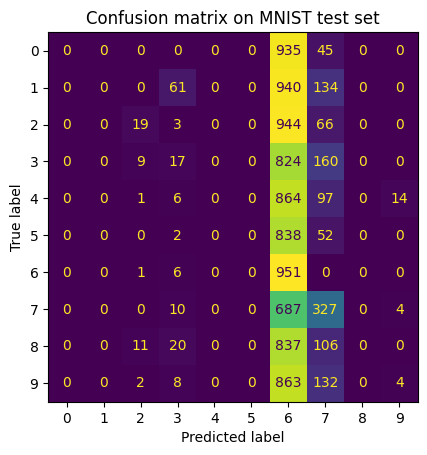

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

model = strategy.server_model  # global model after training
model.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for x, y in TEST_LOADER:
        x = x.to(DEVICE)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy()
        y_pred.extend(list(preds))
        y_true.extend(list(y.numpy()))

cm = confusion_matrix(y_true, y_pred, labels=list(range(10)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
plt.figure(figsize=(6,6))
disp.plot(values_format="d", cmap=None, colorbar=False)
plt.title("Confusion matrix on MNIST test set")
plt.show()


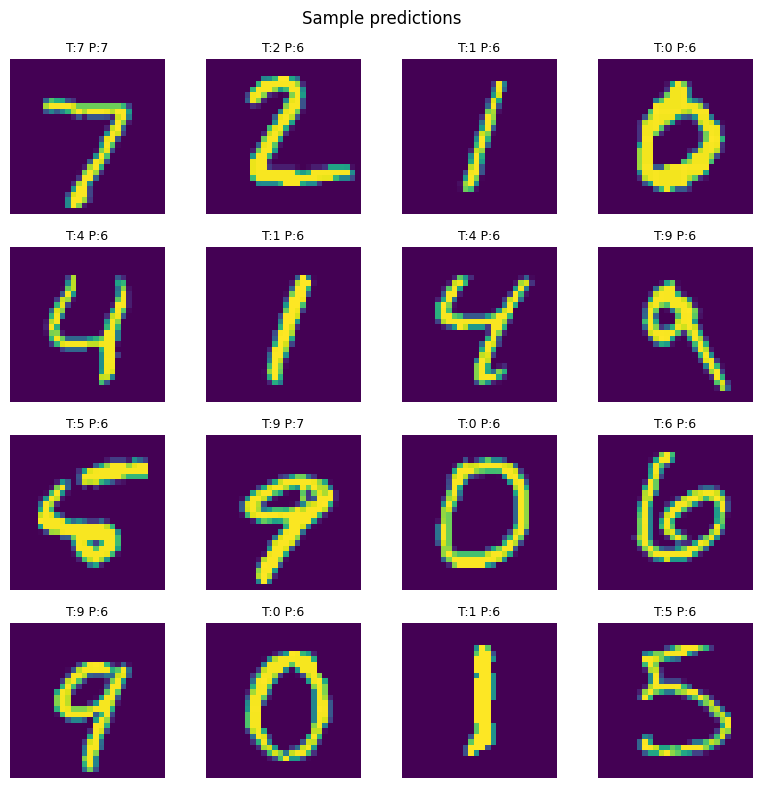

In [27]:
import matplotlib.pyplot as plt

model.eval()
images, labels = next(iter(TEST_LOADER))
with torch.no_grad():
    preds = model(images.to(DEVICE)).argmax(1).cpu()

k = 16  # number of samples to show
plt.figure(figsize=(8,8))
for i in range(k):
    plt.subplot(4,4,i+1)
    plt.imshow(images[i][0], interpolation="nearest")
    plt.title(f"T:{labels[i].item()} P:{preds[i].item()}", fontsize=9)
    plt.axis("off")
plt.suptitle("Sample predictions")
plt.tight_layout()
plt.show()


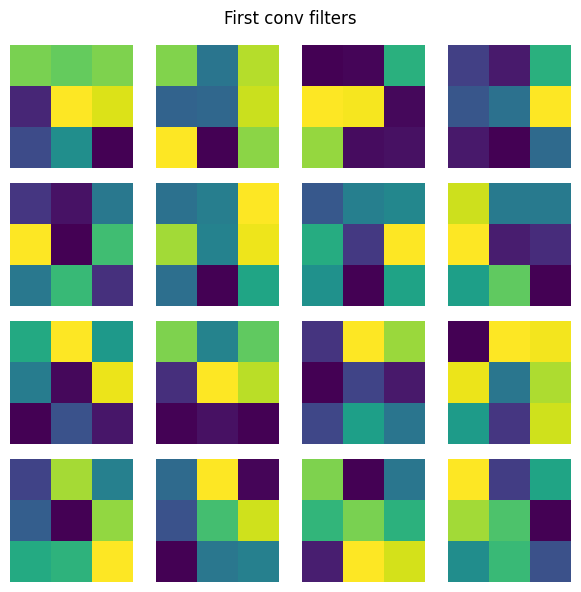

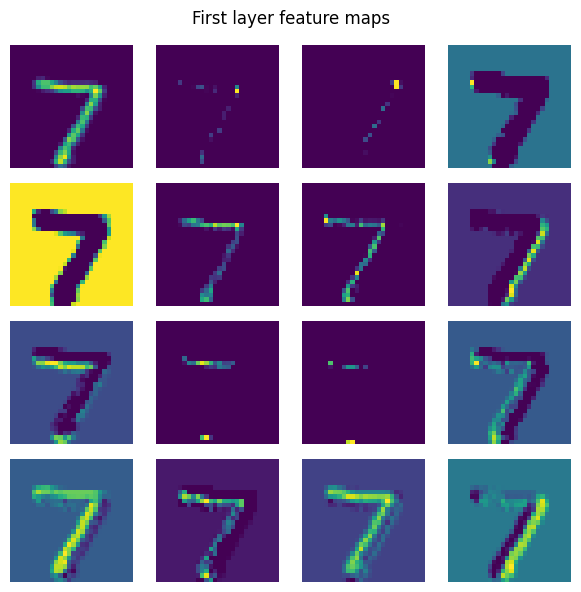

In [28]:
import matplotlib.pyplot as plt

# Plot learned filters from the first conv layer
w = model.c1.weight.detach().cpu().numpy()  # shape [16,1,3,3]
plt.figure(figsize=(6,6))
for i in range(min(16, w.shape[0])):
    plt.subplot(4,4,i+1)
    plt.imshow(w[i,0], interpolation="nearest")
    plt.axis("off")
plt.suptitle("First conv filters")
plt.tight_layout()
plt.show()

# Plot feature maps for a single sample
model.eval()
img = images[0:1].to(DEVICE)  # reuse a batch from TEST_LOADER above
with torch.no_grad():
    fm = torch.relu(model.c1(img)).cpu().squeeze(0)  # shape [16, 28, 28]
plt.figure(figsize=(6,6))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(fm[i], interpolation="nearest")
    plt.axis("off")
plt.suptitle("First layer feature maps")
plt.tight_layout()
plt.show()


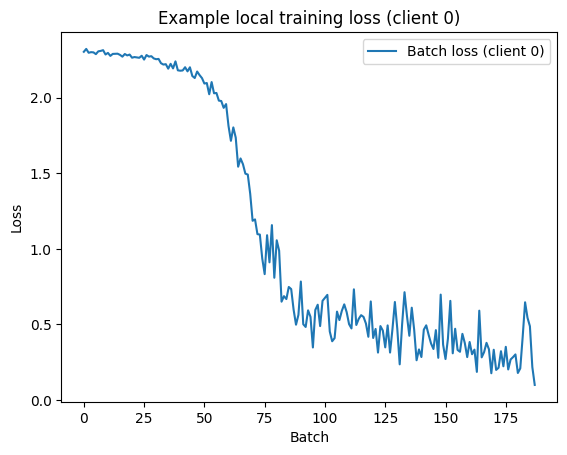

In [29]:
def quick_client_curve(model, loader, device):
    model = SmallCNN().to(device)
    opt = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    crit = nn.CrossEntropyLoss()
    losses = []
    model.train()
    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = crit(model(x), y)
        loss.backward()
        opt.step()
        losses.append(loss.item())
        if i >= 200:  # keep it short
            break
    return losses

curve = quick_client_curve(SmallCNN(), CLIENT_LOADERS[0], DEVICE)
plt.figure()
plt.plot(range(len(curve)), curve, label="Batch loss (client 0)")
plt.xlabel("Batch")
plt.ylabel("Loss")
plt.legend()
plt.title("Example local training loss (client 0)")
plt.show()
